In [162]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter, NullFormatter, ScalarFormatter
import numpy as np
import pandas as pd
import seaborn as sb
import seaborn.objects as so

nCells = {"LDC-S": 1030301, "LDC-M": 8120601, "Wind": 6517376}

df = pd.read_csv("results/results_new.csv", skip_blank_lines=True)
df['time_mean_ns_normed'] = df['time_mean_ms'].apply(lambda x: x *1000000/ nCells["LDC-S"])
filtered = df[~df["variant"].str.contains("Only")]
sorted_variants = sorted(df["variant"].unique())
sorted_variants_filtered = sorted(filtered["variant"].unique())

In [93]:
df

,time_mean_ms,time_median_ms,gc_time_mean_ms,gc_time_median_ms,case_short,case_long,strategy,variant,language,time_mean_ns_normed
0,99.812780,101.696720,4.098518,0.0,LDC-S,LDC-S,faceBased,DivOnlyDynamicCDF,julia,0.000097
1,105.409200,103.057816,8.083513,0.0,LDC-S,LDC-S,faceBased,PrecalculatedWeightsUpwind,julia,0.000102
2,102.978250,101.667290,3.029836,0.0,LDC-S,LDC-S,faceBased,DivOnlyHardCodedUpwind,julia,0.000100
3,42.974182,33.386826,9.064015,0.0,LDC-S,LDC-S,faceBased,LaplaceOnly,julia,0.000042
4,101.436844,96.292114,4.461367,0.0,LDC-S,LDC-S,faceBased,DynamicCDF,julia,0.000098
5,97.600410,94.639046,2.263535,0.0,LDC-S,LDC-S,faceBased,DivOnlyHardCodedCDF,julia,0.000095
6,107.740364,105.830284,2.071796,0.0,LDC-S,LDC-S,faceBased,DivOnlyPrecalculatedWeightsCDF,julia,0.000105
7,113.694130,111.922990,4.249827,0.0,LDC-S,LDC-S,faceBased,HardCodedUpwind,julia,0.000110
8,107.043390,103.750600,2.058672,0.0,LDC-S,LDC-S,faceBased,DivOnlyPrecalculatedWeightsUpwind,julia,0.000104
9,111.251460,109.676130,2.197398,0.0,LDC-S,LDC-S,faceBased,DivOnlyDynamicUpwind,julia,0.000108


In [58]:
def draw_boxplot(data, x, y, save=False, annotate=False, useLog=False, ylabel=""):
    yl = ylabel or y
    plot = sb.boxplot(data=data, x=x, y=y, log_scale=useLog, gap=.1).set(
        ylabel=yl
    )
    if annotate:
        minvals = data.loc[data.groupby("strategy")["time_mean_ms"].idxmin()]
        mapping = {"faceBased": 0, "globalFaceBased": 1, "cellBased": 2}
        for i, row in minvals.iterrows():
            plot.annotate(row["variant"],
                    xy=(mapping[row["strategy"]], row[y]),
                    fontsize=12)
    if save:
        plt.savefig(f"figures/{save}.svg")

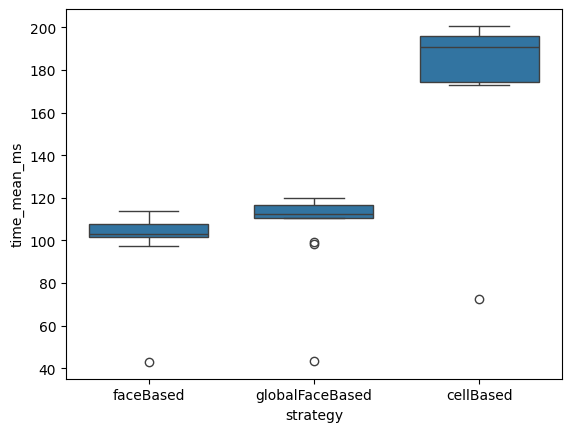

In [59]:
draw_boxplot(df, x="strategy", y="time_mean_ms", save=False, annotate=False)

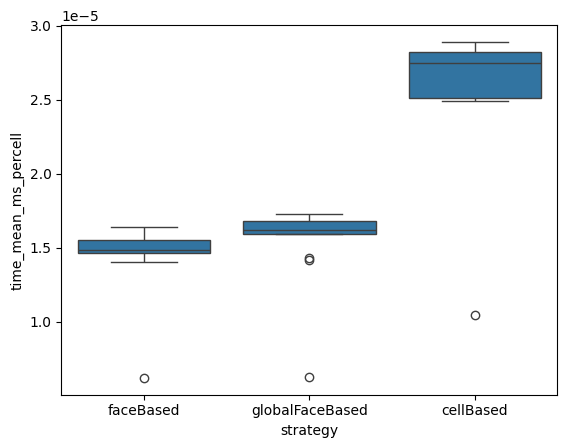

In [9]:
draw_boxplot(df, x="strategy", y="time_mean_ms_percell", save=False, annotate=False)

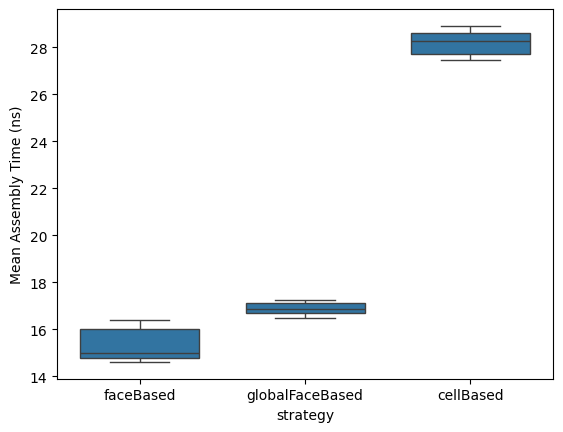

In [ ]:
draw_boxplot(filtered, x="strategy", y="time_mean_ns_normed", ylabel="Mean Assembly Time Per Cell (ns)")


time_mean_ms Mean Assembly Time (ms)
time_mean_ns_normed Mean Assembly Time Per Cell (ms)


/tmp/ipykernel_79124/1145916407.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(),
/tmp/ipykernel_79124/1145916407.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(),


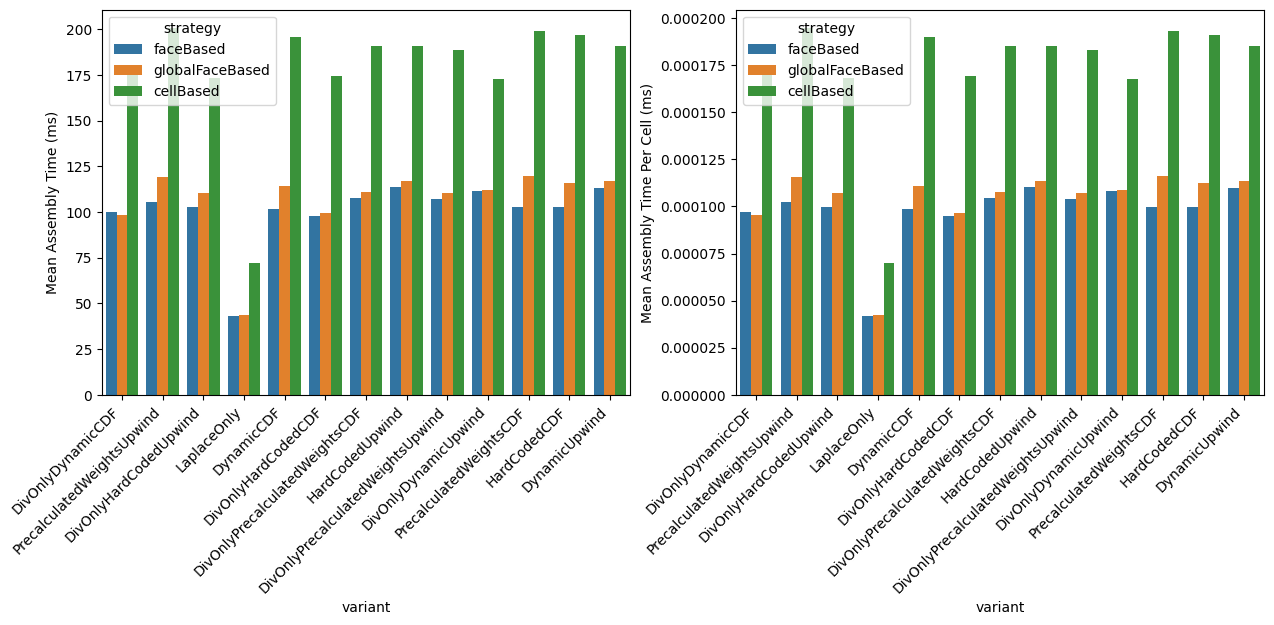

In [94]:
fig, axes = plt.subplots(1,2, figsize=(15, 5))

for i, ax in enumerate(axes.flat):
    y = "time_mean_ms" if i == 0 else "time_mean_ns_normed"
    yl = "Mean Assembly Time (ms)" if i == 0 else "Mean Assembly Time Per Cell (ms)"
    print(y,yl)
    p =  sb.barplot(df, ax=ax, x="variant", y=y, hue="strategy")
    p.set(
        ylabel=yl
    )

    p.set_xticklabels(p.get_xticklabels(), 
                            rotation=45, 
                            horizontalalignment='right'
    )


<class 'matplotlib.text.Text'>
<class 'matplotlib.text.Text'>
<class 'matplotlib.text.Text'>


/tmp/ipykernel_79124/4236769527.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(),


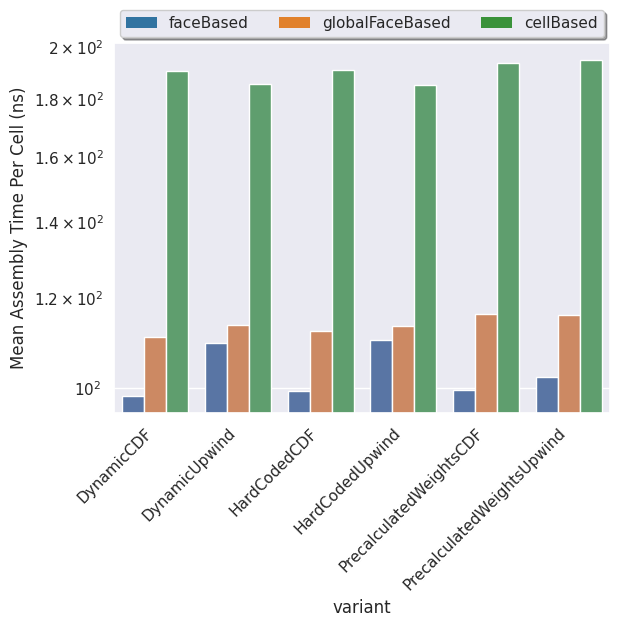

In [ ]:
sb.set_theme()
fig, ax= plt.subplots()
y = "time_mean_ns_normed"
yl = "Mean Assembly Time Per Cell (ns)"
p =  sb.barplot(filtered,ax=ax ,x="variant", y=y, hue="strategy", legend="brief", order=sorted_variants_filtered)
p.set_yscale("log")
p.set(
    ylabel=yl
)

p.set_xticklabels(p.get_xticklabels(), 
                        rotation=45, 
                        horizontalalignment='right'
)
labels = ax.get_legend_handles_labels()[1]
ax.legend().remove()

for t, new_label in zip(ax.legend().texts, labels):
    print(type(t))
    t.set_text(new_label)
handles, labels = axes[0].get_legend_handles_labels()
plt.legend(handles, labels, loc="upper center", bbox_to_anchor = (0.5,1.11),ncol=6, fancybox=True, shadow=True)
plt.savefig(f"figures/test.svg")
